In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [19]:
# Quick look
print('shape:',df.shape)
print('null:',df.isnull().sum().sum())

shape: (1470, 35)
null: 0


In [20]:
# Overall attrition rate
df["AttritionFlag"] = df["Attrition"].map({"Yes": 1, "No": 0})
print("Overall Attrition Rate:", df["AttritionFlag"].mean() * 100)

Overall Attrition Rate: 16.122448979591837


In [22]:
# Tenure buckets
def tenure_bucket(years):
    if years <= 2:
        return "0-2 yrs"
    elif years <= 5:
        return "3-5 yrs"
    elif years <= 10:
        return "6-10 yrs"
    else:
        return "10+ yrs"

df["TenureBucket"] = df["YearsAtCompany"].apply(tenure_bucket)

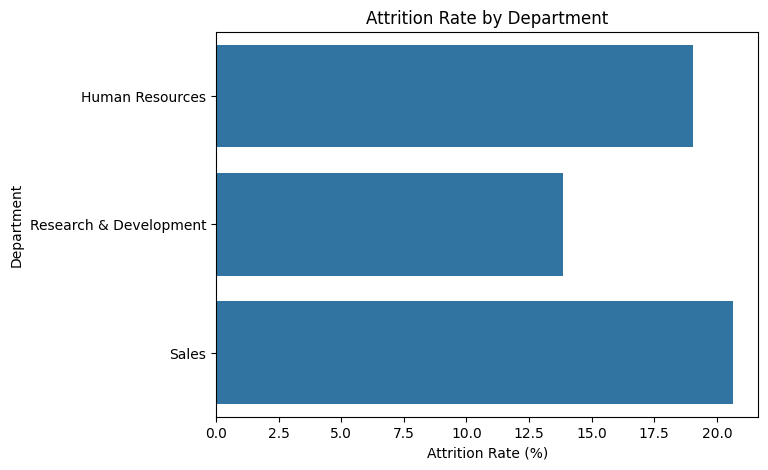

In [23]:
# 1. Attrition by Department
dept_rate = df.groupby("Department")["AttritionFlag"].mean() * 100
plt.figure(figsize=(7,5))
sns.barplot(x=dept_rate.values, y=dept_rate.index)
plt.xlabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")
plt.show()

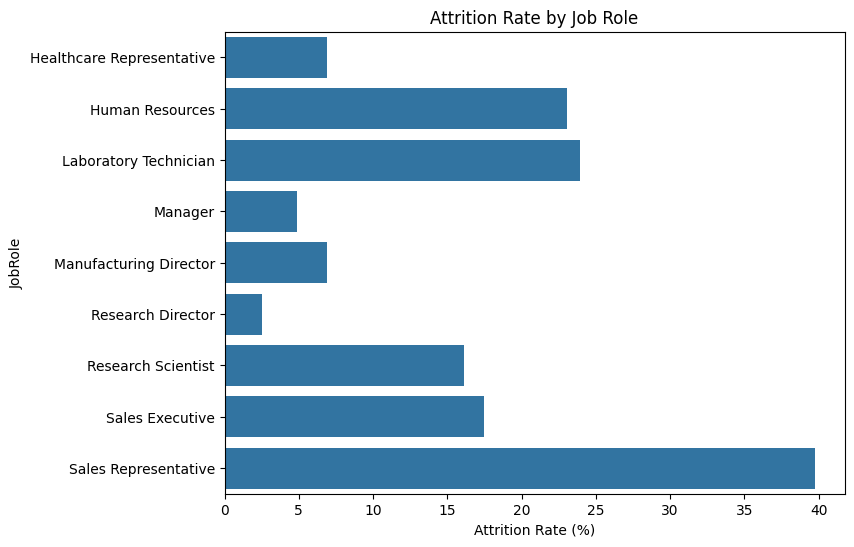

In [24]:
# 2. Attrition by Job Role
role_rate = df.groupby("JobRole")["AttritionFlag"].mean() * 100
plt.figure(figsize=(8,6))
sns.barplot(x=role_rate.values, y=role_rate.index)
plt.xlabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")
plt.show()

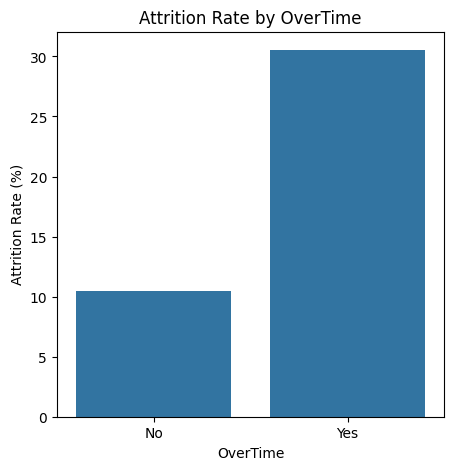

In [25]:
# 3. Attrition by OverTime
ot_rate = df.groupby("OverTime")["AttritionFlag"].mean() * 100
plt.figure(figsize=(5,5))
sns.barplot(x=ot_rate.index, y=ot_rate.values)
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by OverTime")
plt.show()

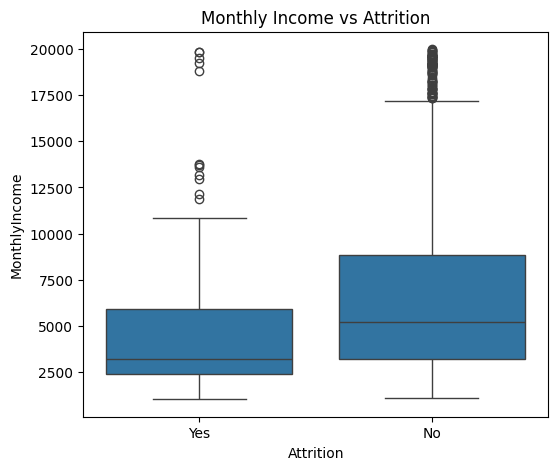

In [26]:
# 4. Monthly Income vs Attrition
plt.figure(figsize=(6,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

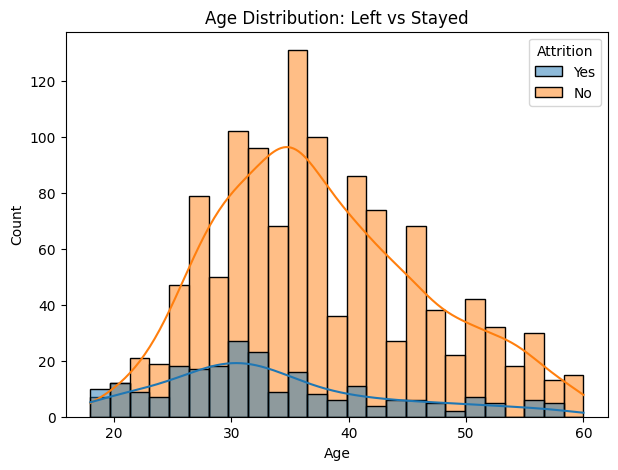

In [27]:
# 5. Age distribution: left vs stayed
plt.figure(figsize=(7,5))
sns.histplot(data=df, x="Age", hue="Attrition", kde=True, bins=25)
plt.title("Age Distribution: Left vs Stayed")
plt.show()

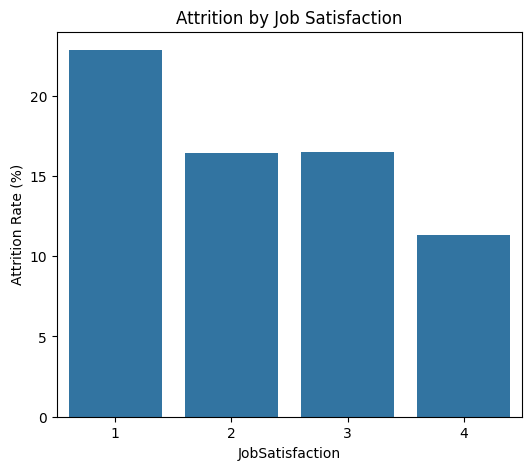

In [28]:
# 6. Attrition by Job Satisfaction
js_rate = df.groupby("JobSatisfaction")["AttritionFlag"].mean() * 100
plt.figure(figsize=(6,5))
sns.barplot(x=js_rate.index, y=js_rate.values)
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition by Job Satisfaction")
plt.show()

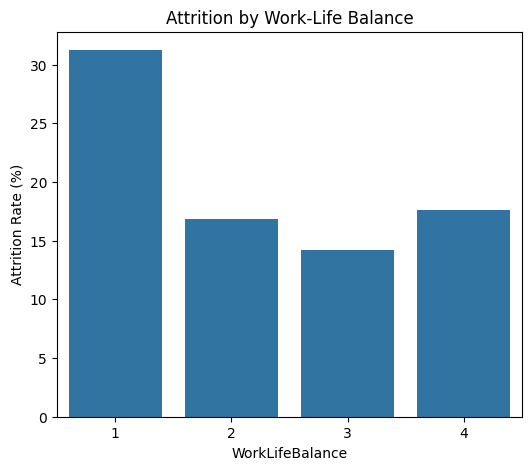

In [29]:
# 7. Attrition by Work-Life Balance
wlb_rate = df.groupby("WorkLifeBalance")["AttritionFlag"].mean() * 100
plt.figure(figsize=(6,5))
sns.barplot(x=wlb_rate.index, y=wlb_rate.values)
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition by Work-Life Balance")
plt.show()

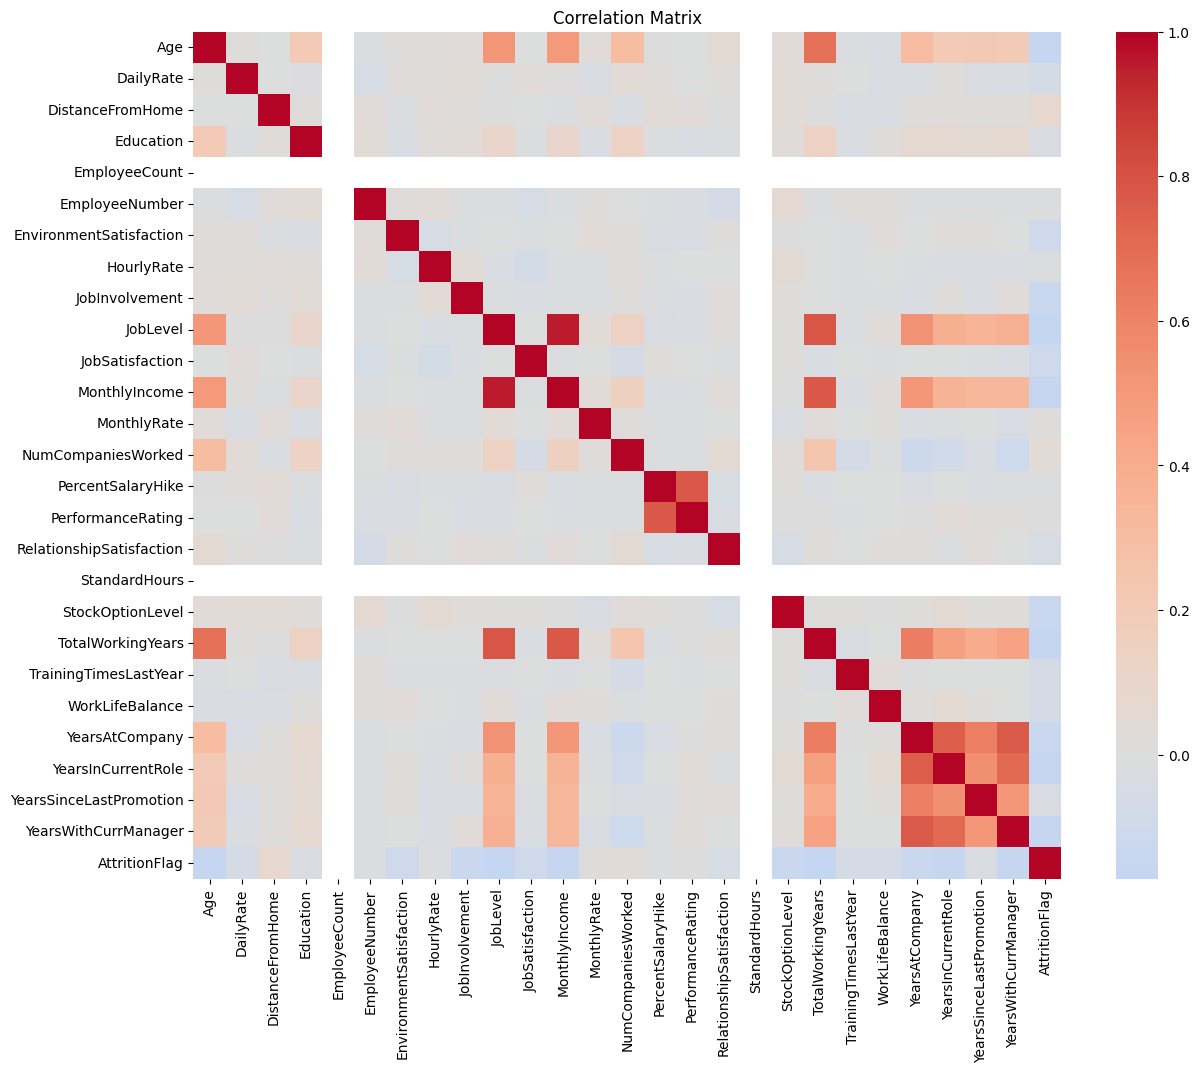

In [30]:
# 8. Correlation heatmap
plt.figure(figsize=(14,11))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

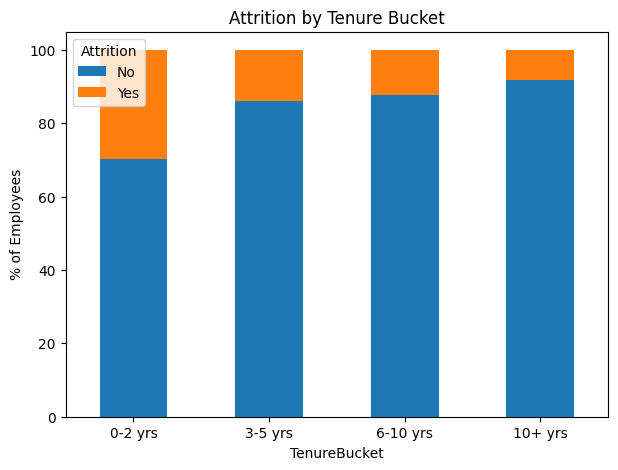

In [31]:
# 9. Attrition by Tenure Bucket (stacked bar)
tenure_order = ["0-2 yrs", "3-5 yrs", "6-10 yrs", "10+ yrs"]
tenure_ct = pd.crosstab(df["TenureBucket"], df["Attrition"], normalize="index").reindex(tenure_order) * 100
tenure_ct.plot(kind="bar", stacked=True, figsize=(7,5))
plt.ylabel("% of Employees")
plt.title("Attrition by Tenure Bucket")
plt.xticks(rotation=0)
plt.show()

In [32]:
# Key insights printout
print("Attrition by Department:\n", dept_rate.sort_values(ascending=False))
print("Attrition by OverTime:\n", ot_rate)
print("Attrition by Tenure Bucket:\n", tenure_ct)

Attrition by Department:
 Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: AttritionFlag, dtype: float64
Attrition by OverTime:
 OverTime
No     10.436433
Yes    30.528846
Name: AttritionFlag, dtype: float64
Attrition by Tenure Bucket:
 Attrition            No        Yes
TenureBucket                      
0-2 yrs       70.175439  29.824561
3-5 yrs       86.175115  13.824885
6-10 yrs      87.723214  12.276786
10+ yrs       91.869919   8.130081
